In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Myriad Pro'
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 600

import numpy as np
import time

from ipcc_colormap import *
from utils import *

from matplotlib import gridspec
from matplotlib.colorbar import ColorbarBase


coastline = gpd.read_file('/home/mizu_home/xp53/nas/home/coastlines-split-SGregion/lines.shp')
mask = np.loadtxt('mask.txt')

ipcc_blue = (112.0/255, 160.0/255, 205.0/255, 1.0)
ipcc_orange = (196.0/255, 121.0/255, 0.0/255, 1.0)

tmp_cmap = ipcc_cmap()
tmp_cmap.read_rgb_data_from_excel()
;

2025-09-01 10:57:52.686317: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-01 10:57:52.771814: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


''

In [2]:
# Grid coordinates
longlat = np.loadtxt('data/lonlat.txt')
lons = longlat[0, :].reshape(120, 160)
lats = longlat[1, :].reshape(120, 160)

# read station lons (3rd column) and lats (4th column)
sta_loc = np.genfromtxt('data/sta_lookup_new.csv', delimiter=',')[:, 2:]

# Load and process CMIP6-forced future climate data
cmip_rain_raw = np.loadtxt('data/wrf_monthly_cmip.txt')[-40:, :]
cmip_rain_temp = cmip_rain_raw.reshape(40, 12, 120, 160)

# Shift calendar: July starts CMIP simulations -> align with Jan-Dec
cmip_rain_aligned = np.zeros(cmip_rain_temp.shape)
cmip_rain_aligned[:, 0:6, :, :] = cmip_rain_temp[:, 6:12, :, :]  # Jan-Jun from Jul-Dec
cmip_rain_aligned[:, 6:12, :, :] = cmip_rain_temp[:, 0:6, :, :]  # Jul-Dec from Jan-Jun

# Initialize plotter and colormap
sg_plotter = sg_map_plotter(lons, lats, coastline)
CMAP = tmp_cmap.get_ipcc_cmap('seq', 'prec', 20)  # 'prec' for precipitation MAP
# Plotting setup
month_labels = ['(a) Jan', '(b) Feb', '(c) Mar', '(d) Apr', '(e) May', '(f) Jun', 
                '(g) Jul', '(h) Aug', '(i) Sep', '(j) Oct', '(k) Nov', '(l) Dec']

In [4]:
def create_monthly_maps(plot_data, plot_type='mean', vmin=0, vmax=400, 
                       colorbar_label='Rainfall [mm]', filename_suffix='', cmap=CMAP):
    """
    Create 12-panel monthly maps for Singapore.
    
    Args:
        plot_data: List of 12 arrays (one per month) to plot
        plot_type: Type of plot ('mean', 'std', 'diff')
        vmin, vmax: Color scale limits
        colorbar_label: Label for colorbar
        filename_suffix: Suffix for output filename
    """
    fig = plt.figure(figsize=(11, 10))
    gs = gridspec.GridSpec(4, 3, height_ratios=[1,1,1,1], bottom=0.1, top=0.95, 
                          left=0.05, right=0.95, wspace=0.05, hspace=0.05)
    
    axes = [plt.subplot(gs[i, j], projection=crs.PlateCarree()) 
            for i in range(4) for j in range(3)]
    
    for month_idx, ax in enumerate(axes):
        sg_plotter.plot_(ax, plot_data[month_idx], cmap=cmap, vmin=vmin, vmax=vmax)
        sg_plotter.plot_scatter(ax, sta_loc, size=15)
        ax.text(0.03, 0.95, month_labels[month_idx], transform=ax.transAxes, 
                fontsize=10, verticalalignment='top', 
                bbox=dict(facecolor='white', alpha=0.6))
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.06, 0.07, 0.88, 0.015])
    bounds = np.linspace(vmin, vmax, 21)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    cb = ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='horizontal')
    cb.ax.tick_params(labelsize=12)
    cb.set_label(colorbar_label, fontsize=12, fontweight='bold')
    
    # Save figure
    output_path = f'for_pub.pdf'
    fig.savefig(output_path)
    print(f'Saved: {output_path}')
    
    return fig


Creating rainfall climatology map...
Saved: for_pub.pdf


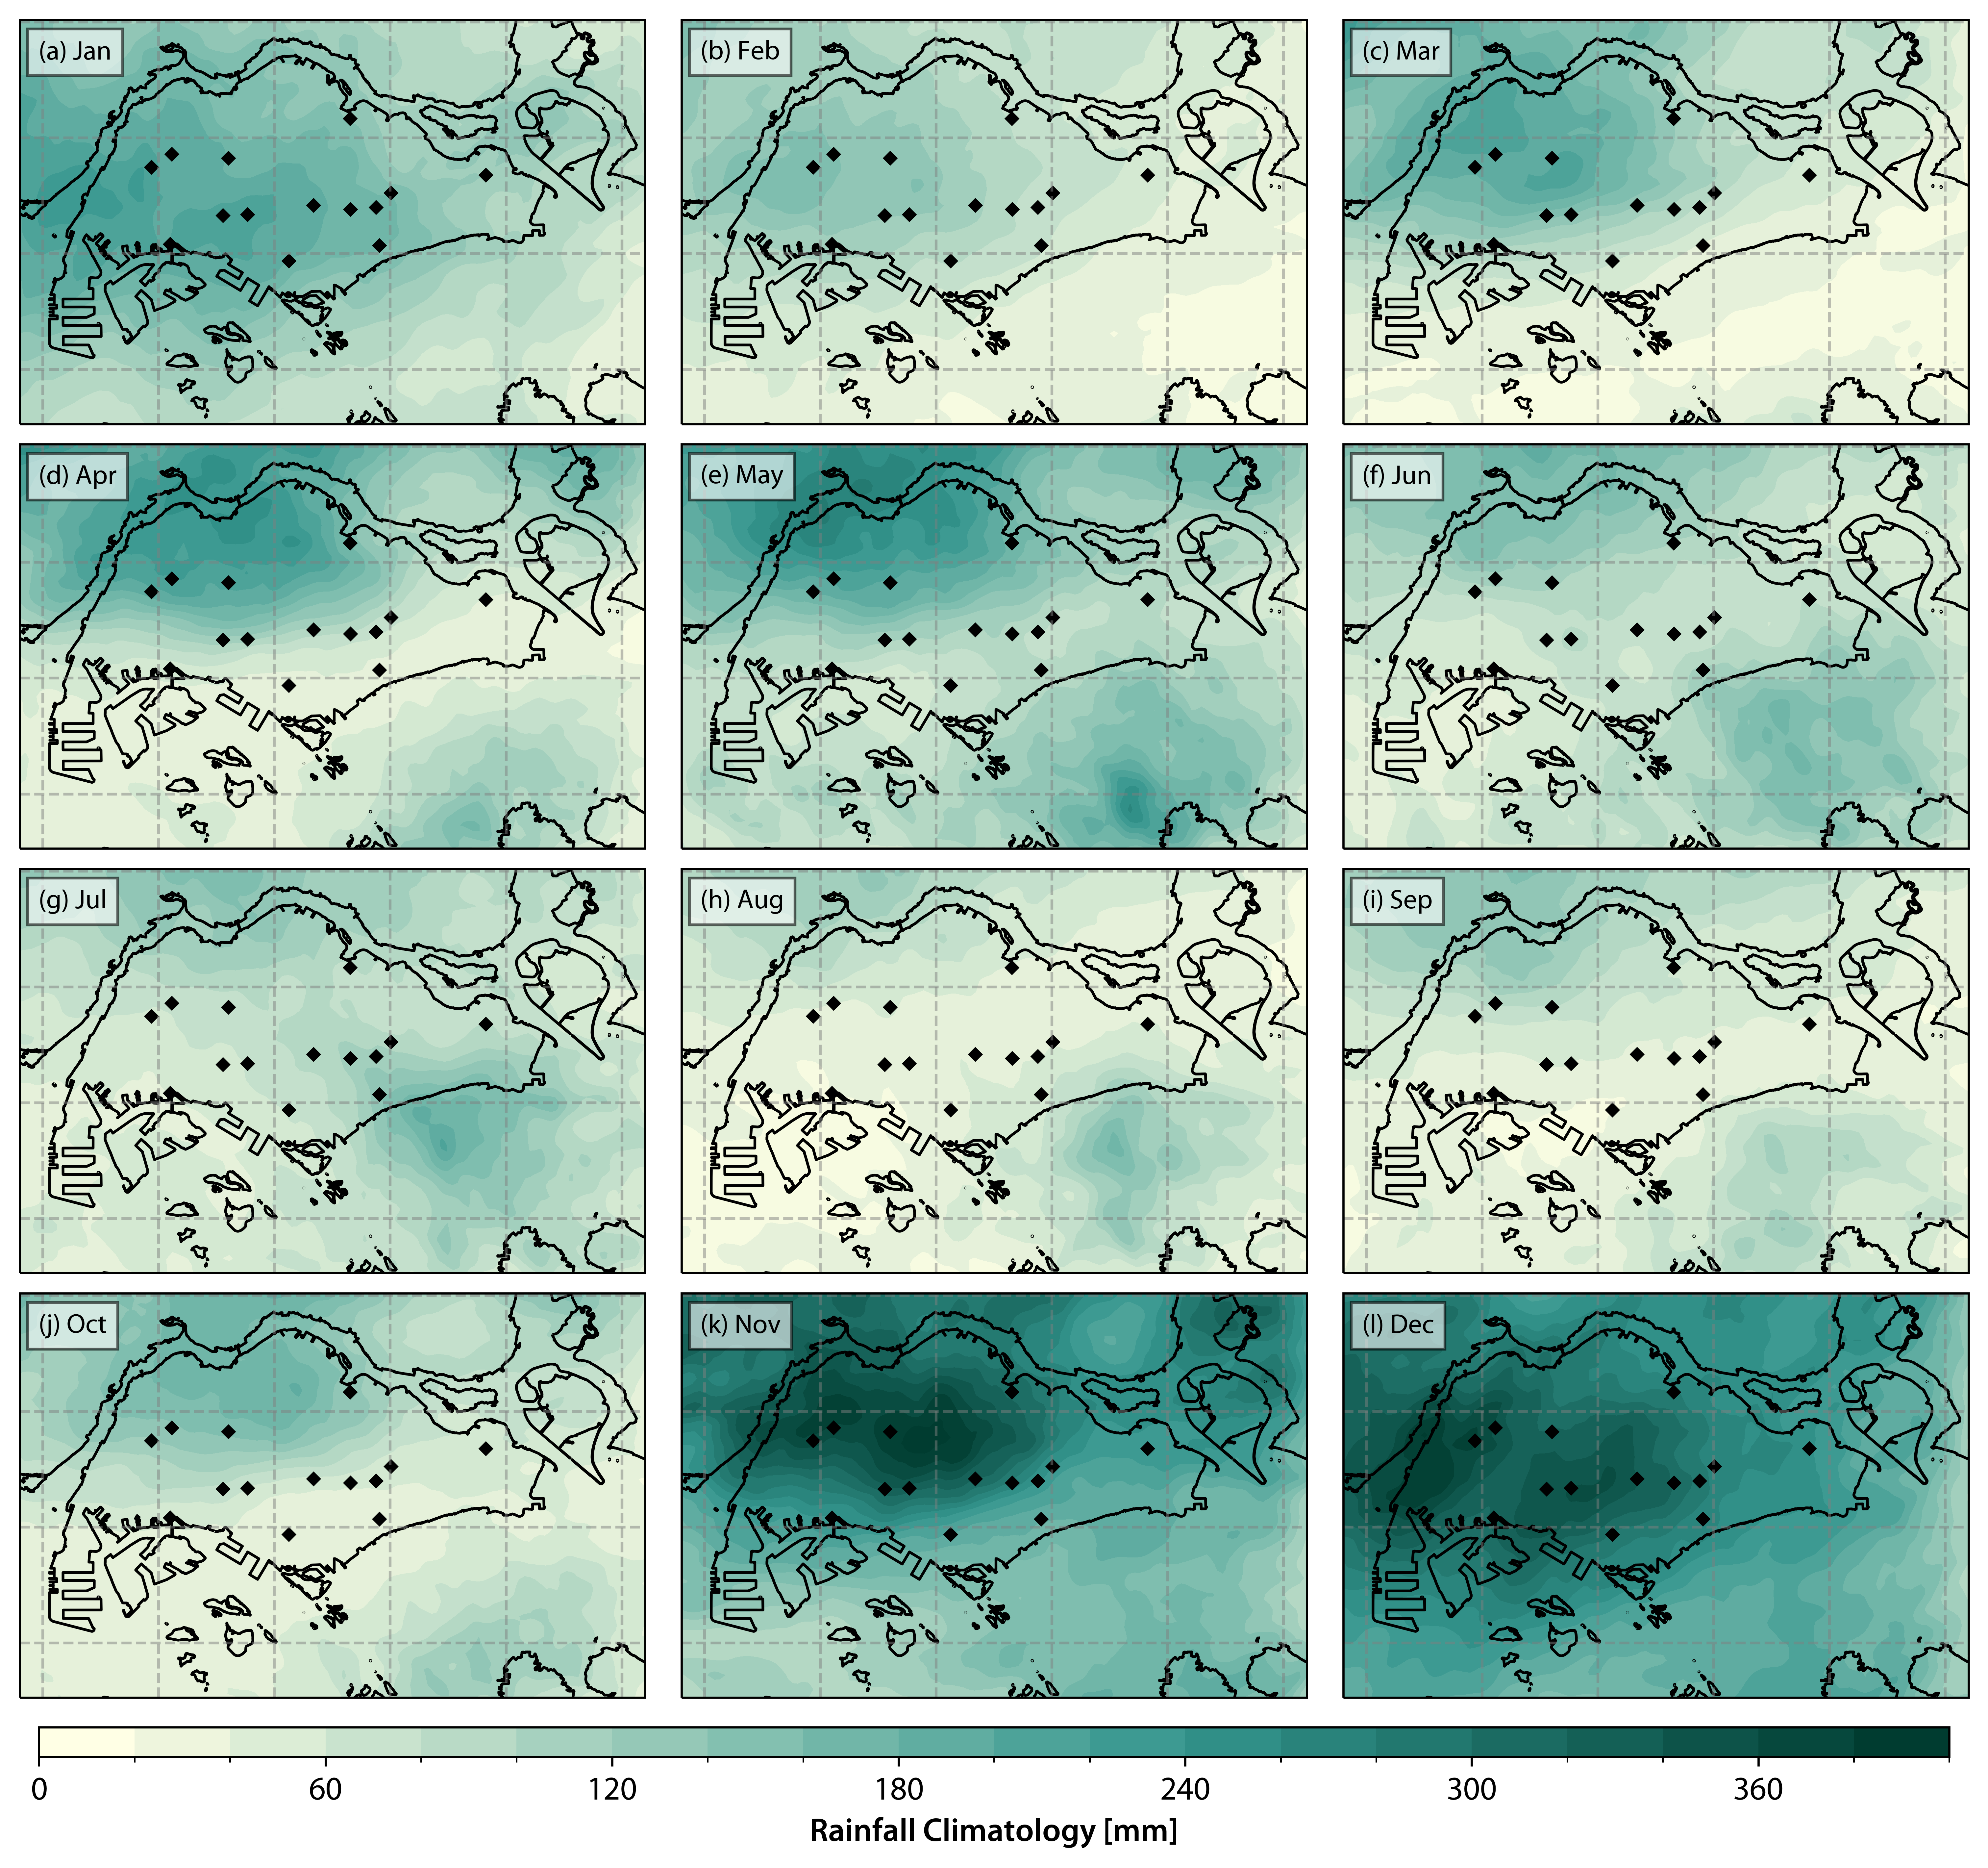

In [6]:
print("\nCreating rainfall climatology map...")
monthly_mean = np.mean(cmip_rain_aligned, axis=0)
create_monthly_maps(
    plot_data=monthly_mean,
    plot_type='climatology',
    vmin=0, vmax=400,
    colorbar_label='Rainfall Climatology [mm]',
    filename_suffix='historical'
)

In [10]:
lats.shape

(120, 160)

In [7]:
monthly_mean.shape

(12, 120, 160)

In [11]:
# Create CSV file with monthly rainfall data
print("Creating CSV file with monthly rainfall data...")

# Flatten the spatial dimensions to create arrays for each coordinate
lats_flat = lats.flatten()
lons_flat = lons.flatten()

# Create a DataFrame with longitude and latitude columns
import pandas as pd

# Month names for column headers
month_names = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 
               'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

# Initialize the DataFrame with LON and LAT columns
df_data = {
    'LON': lons_flat,
    'LAT': lats_flat
}

# Add monthly rainfall data (flatten each month's 2D array)
for month_idx, month_name in enumerate(month_names):
    df_data[month_name] = monthly_mean[month_idx].flatten()

# Create DataFrame
df = pd.DataFrame(df_data)

# Save to CSV
output_csv = 'singapore_monthly_rainfall.csv'
df.to_csv(output_csv, index=False)
print(f'Saved monthly rainfall data to: {output_csv}')
print(f'CSV shape: {df.shape}')



Creating CSV file with monthly rainfall data...
Saved monthly rainfall data to: singapore_monthly_rainfall.csv
CSV shape: (19200, 14)
